**Prática de Realce e detecção de borda**

Exercícios retirados de:
http://homepages.inf.ed.ac.uk/rbf/HIPR2/featops.htm



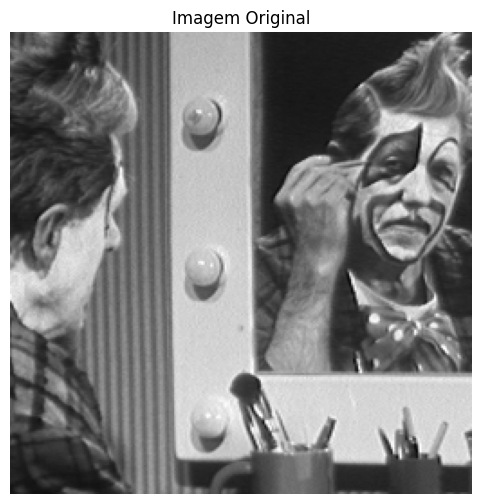

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("cln1.png", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro: Imagem não encontrada. Verifique o nome do arquivo.")
else:
    plt.figure(figsize=(6, 6))
    plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
    plt.title("Imagem Original")
    plt.axis('off') 
    plt.show()

1) Aplique os filtros  Sobel e Roberts nas imagens abaixo. Mostre, para o caso do Sobel, uma imagem representando a derivada em x e outra imagem representando a derivada em y

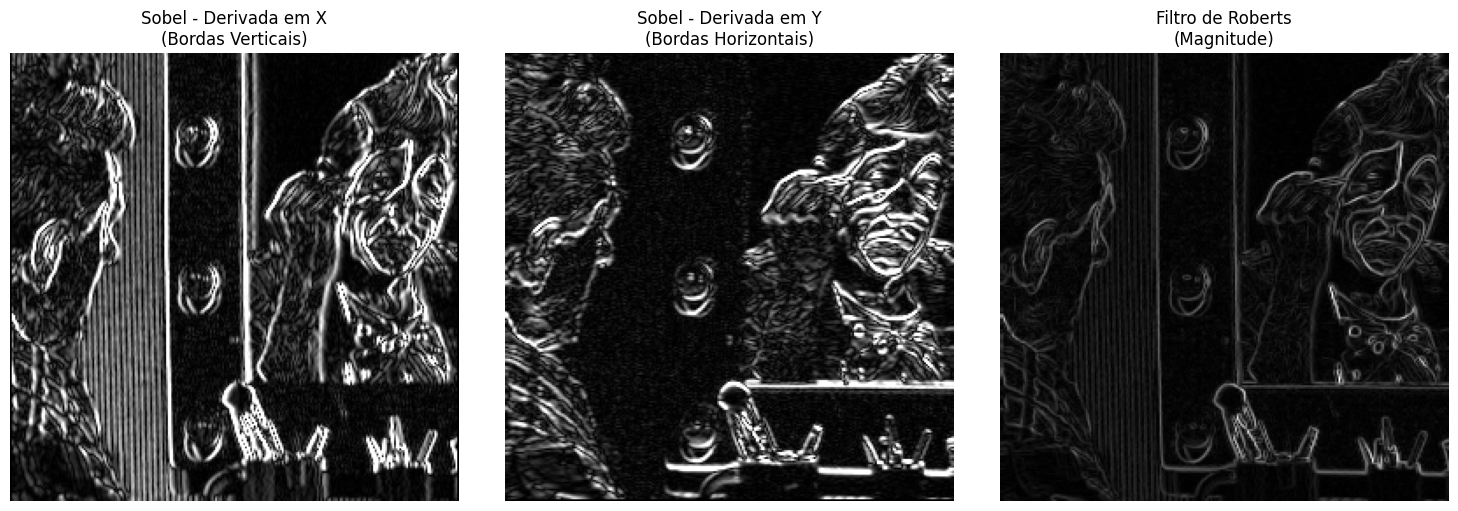

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('cln1.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Erro: Imagem 'cln1.png' não encontrada.")
else:

    kernel_sobel_x = np.array([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]])

    kernel_sobel_y = np.array([[-1, -2, -1],
                               [ 0,  0,  0],
                               [ 1,  2,  1]])

    sobel_x = cv2.filter2D(img, cv2.CV_64F, kernel_sobel_x)
    sobel_y = cv2.filter2D(img, cv2.CV_64F, kernel_sobel_y)
    
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)

   
    kernel_roberts_x = np.array([[1, 0],
                                 [0, -1]])
    
    kernel_roberts_y = np.array([[0, 1],
                                 [-1, 0]])

    #convolução
    roberts_x = cv2.filter2D(img, cv2.CV_64F, kernel_roberts_x)
    roberts_y = cv2.filter2D(img, cv2.CV_64F, kernel_roberts_y)

    roberts_combined = cv2.magnitude(roberts_x, roberts_y)
    abs_roberts = cv2.convertScaleAbs(roberts_combined)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(abs_sobel_x, cmap='gray')
    plt.title('Sobel - Derivada em X\n(Bordas Verticais)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(abs_sobel_y, cmap='gray')
    plt.title('Sobel - Derivada em Y\n(Bordas Horizontais)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(abs_roberts, cmap='gray')
    plt.title('Filtro de Roberts\n(Magnitude)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

2) Utilizando a imagem do exercício anterior, realce as bordas utilizando (a) Filtro Laplaciano. (b) Unsharp masking. (c) Highboost filtering (escolher um k). (d) K <1 para atenuar

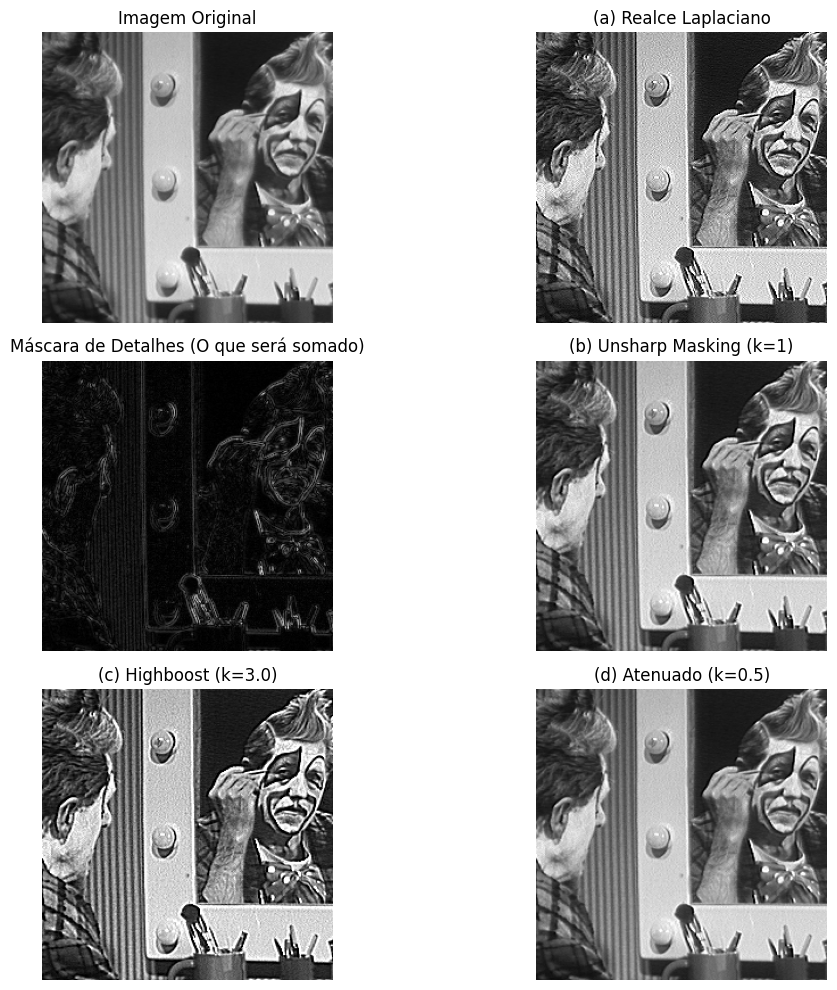

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagem_original = cv2.imread('cln1.png', cv2.IMREAD_GRAYSCALE)

if imagem_original is None:
    print("Erro: A imagem 'cln1.png' não foi encontrada.")
else:
    kernel_laplaciano = np.array([[0,  1, 0],
                                  [1, -4, 1],
                                  [0,  1, 0]])

    resposta_laplaciano = cv2.filter2D(imagem_original, cv2.CV_64F, kernel_laplaciano)

    img_float = imagem_original.astype(np.float32)
    imagem_laplaciano = img_float - resposta_laplaciano
    imagem_laplaciano = np.clip(imagem_laplaciano, 0, 255).astype(np.uint8)

    imagem_suavizada = cv2.GaussianBlur(imagem_original, (5, 5), 2.0)
    
    mascara_detalhes = img_float - imagem_suavizada.astype(np.float32)

    k_padrao = 1
    
    imagem_unsharp = img_float + (k_padrao * mascara_detalhes)
    imagem_unsharp = np.clip(imagem_unsharp, 0, 255).astype(np.uint8)


    k_alto = 3.0  
    imagem_highboost = img_float + (k_alto * mascara_detalhes)
    imagem_highboost = np.clip(imagem_highboost, 0, 255).astype(np.uint8)

    k_baixo = 0.5
    imagem_atenuada = img_float + (k_baixo * mascara_detalhes)
    imagem_atenuada = np.clip(imagem_atenuada, 0, 255).astype(np.uint8)


    plt.figure(figsize=(12, 10))

    plt.subplot(3, 2, 1)
    plt.imshow(imagem_original, cmap='gray')
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(3, 2, 2)
    plt.imshow(imagem_laplaciano, cmap='gray')
    plt.title('(a) Realce Laplaciano')
    plt.axis('off')

    plt.subplot(3, 2, 3)
    
    plt.imshow(cv2.convertScaleAbs(mascara_detalhes), cmap='gray')
    plt.title('Máscara de Detalhes')
    plt.axis('off')

    plt.subplot(3, 2, 4)
    plt.imshow(imagem_unsharp, cmap='gray')
    plt.title(f'(b) Unsharp Masking (k={k_padrao})')
    plt.axis('off')

    plt.subplot(3, 2, 5)
    plt.imshow(imagem_highboost, cmap='gray')
    plt.title(f'(c) Highboost (k={k_alto})')
    plt.axis('off')

    plt.subplot(3, 2, 6)
    plt.imshow(imagem_atenuada, cmap='gray')
    plt.title(f'(d) Atenuado (k={k_baixo})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

3) Aplique o operador Sobel imagem original abaixo e obtenha as outras imagens conforme descrição. We can see that the intensity of many pixels on the surface is as high as along the actual edges. One reason is that the output of many edge pixels is greater than the maximum pixel value and therefore they are `cut off' at 255. To avoid this overflow we scale the range image by a factor 0.25 prior to the edge detection and then normalize the output, as can be seen in (c)

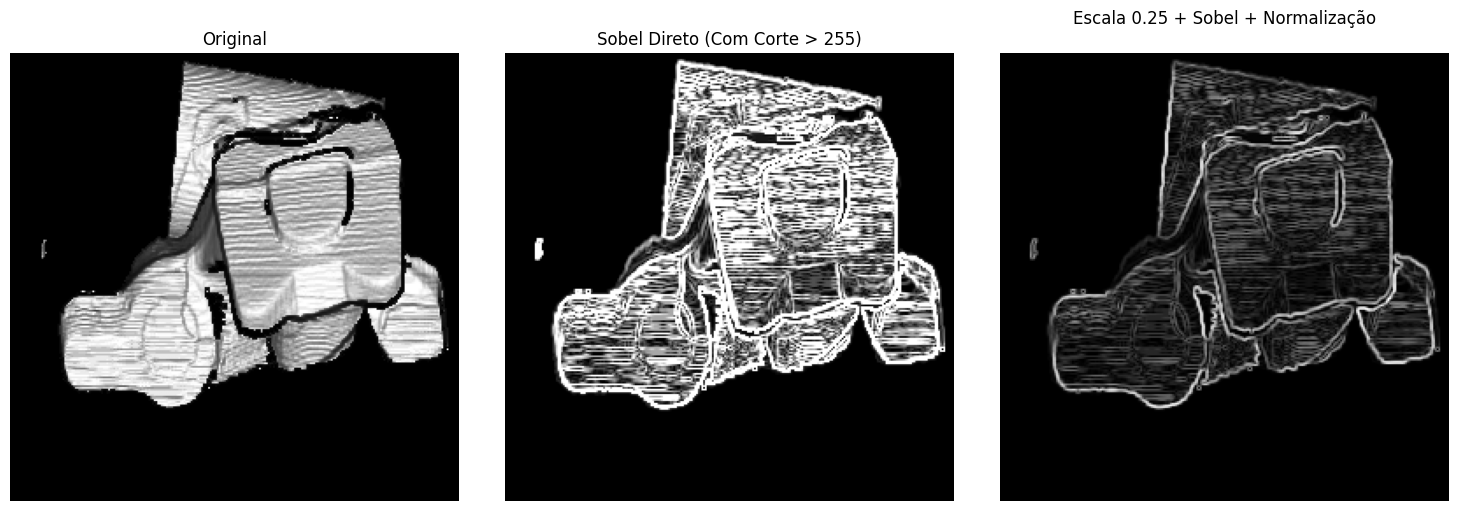

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagem_original = cv2.imread("ren1.png", cv2.IMREAD_GRAYSCALE)

if imagem_original is None:
    print("Erro: Imagem não encontrada.")
else:
    kernel_sobel_x = np.array([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]])

    kernel_sobel_y = np.array([[-1, -2, -1],
                               [ 0,  0,  0],
                               [ 1,  2,  1]])

    sob_x_direto = cv2.filter2D(imagem_original, cv2.CV_64F, kernel_sobel_x)
    sob_y_direto = cv2.filter2D(imagem_original, cv2.CV_64F, kernel_sobel_y)
    
    mag_direto = cv2.magnitude(sob_x_direto, sob_y_direto)
    
    imagem_com_corte = np.clip(mag_direto, 0, 255).astype(np.uint8)

    fator = 0.25
    imagem_float = imagem_original.astype(np.float32)
    imagem_escalada = imagem_float * fator

    sob_x_esc = cv2.filter2D(imagem_escalada, -1, kernel_sobel_x)
    sob_y_esc = cv2.filter2D(imagem_escalada, -1, kernel_sobel_y)
    
    mag_escalada = cv2.magnitude(sob_x_esc, sob_y_esc)

    imagem_normalizada = cv2.normalize(mag_escalada, None, 0, 255, cv2.NORM_MINMAX)
    imagem_normalizada = imagem_normalizada.astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(imagem_original, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(imagem_com_corte, cmap='gray')
    plt.title('Sobel Direto (Com Corte > 255)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(imagem_normalizada, cmap='gray')
    plt.title('Escala 0.25 + Sobel + Normalização\n')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

4) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

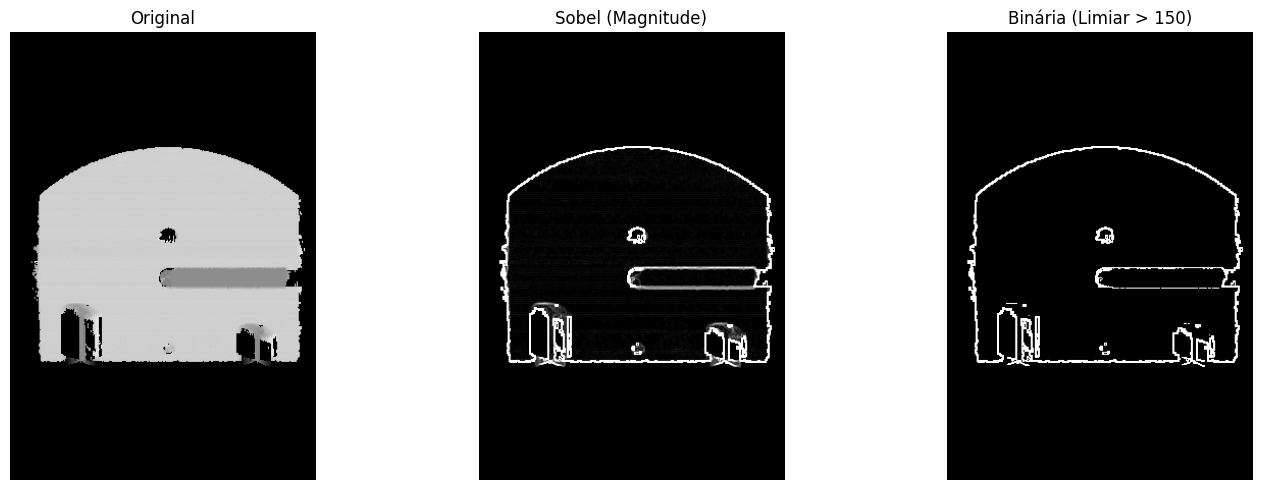

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagem = cv2.imread("ufo2.png", cv2.IMREAD_GRAYSCALE)

if imagem is None:
    print("Erro: A imagem não foi encontrada.")
else:
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])

    kernel_y = np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]])

    sobel_x = cv2.filter2D(imagem, cv2.CV_64F, kernel_x)
    sobel_y = cv2.filter2D(imagem, cv2.CV_64F, kernel_y)

    magnitude = cv2.magnitude(sobel_x, sobel_y)

    magnitude_uint8 = cv2.convertScaleAbs(magnitude)
    valor_limiar = 150
    valor_maximo = 255
    _, imagem_binaria = cv2.threshold(magnitude_uint8, valor_limiar, valor_maximo, cv2.THRESH_BINARY)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(imagem, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(magnitude_uint8, cmap='gray')
    plt.title('Sobel (Magnitude)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(imagem_binaria, cmap='gray')
    plt.title(f'Binária (Limiar > {valor_limiar})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

5) Aplique o operador Sobel imagem original abaixo e obtenha a imagem binária após a limiarização utilizando o valor 150

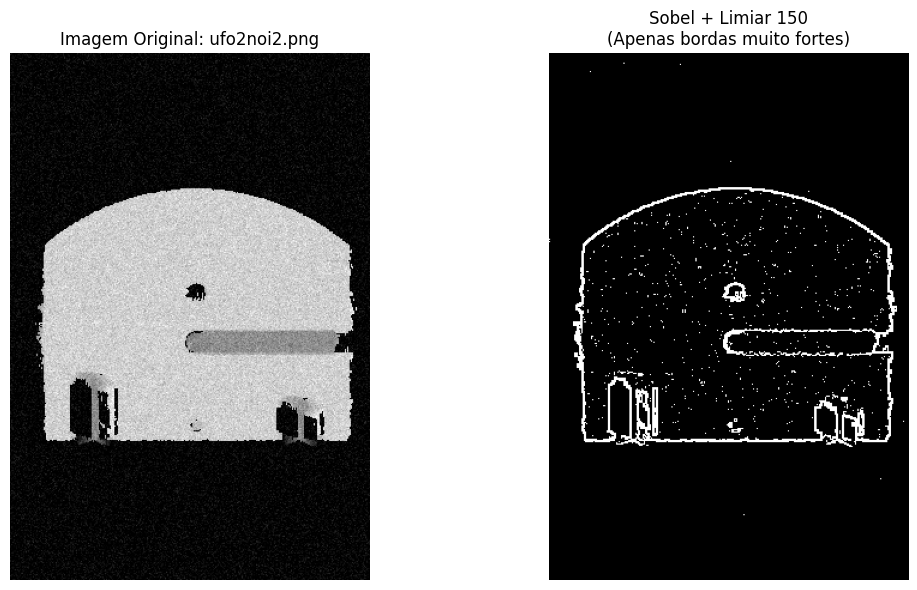

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nome_arquivo = 'ufo2noi2.png'
imagem = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if imagem is None:
    print(f"Erro: A imagem '{nome_arquivo}' não foi encontrada.")
else:
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])

    kernel_y = np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]])

    sobel_x = cv2.filter2D(imagem, cv2.CV_64F, kernel_x)
    sobel_y = cv2.filter2D(imagem, cv2.CV_64F, kernel_y)

    magnitude = cv2.magnitude(sobel_x, sobel_y)
    
    magnitude_uint8 = cv2.convertScaleAbs(magnitude)

    valor_corte = 150
    _, imagem_binaria = cv2.threshold(magnitude_uint8, valor_corte, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(imagem, cmap='gray')
    plt.title(f'Imagem Original: {nome_arquivo}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(imagem_binaria, cmap='gray')
    plt.title(f'Sobel + Limiar {valor_corte}\n(Apenas bordas muito fortes)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()